# Physics-Informed Neural Network: Kepler's Equation

## Problem

In orbital mechanics, the **Eccentric Anomaly** $E(t)$ is related to time $t$ (the Mean Anomaly) via **Kepler's Equation**:

$$E(t) - e\sin(E(t)) = t, \quad t \in [0, 2\pi]$$

where $e \in [0,1)$ is the orbital eccentricity. No closed-form inverse exists, making this a natural target for a PINN.

## PINN Approach

Rather than training on labeled $(t, E)$ pairs (which would require a numerical solver), we encode Kepler's equation directly into the loss. The network $\mathcal{N}(t; \theta)$ approximates $E(t)$ by minimizing the **physics residual**:

$$\mathcal{L}(\theta) = \frac{1}{N}\sum_{i=1}^{N}\left(\mathcal{N}(t_i,\theta) - e\sin\bigl(\mathcal{N}(t_i,\theta)\bigr) - t_i\right)^2$$

At the optimum $\mathcal{L}=0$, the network output satisfies Kepler's equation exactly. The training points $\{t_i\}$ are **randomly resampled each epoch** — this stochastic collocation prevents overfitting to a fixed grid and is standard in PINN training.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

torch.manual_seed(42)
np.random.seed(42)

# Problem constants
E_ORBIT = 0.8          # eccentricity
BATCH_SIZE = 40        # collocation points per epoch
EPOCHS = 8000
LR = 1e-3

device = torch.device('cpu')
print(f'Eccentricity e = {E_ORBIT}, batch size N = {BATCH_SIZE}, epochs = {EPOCHS}')

Eccentricity e = 0.8, batch size N = 40, epochs = 8000


## Network Architecture

We use a fully-connected network with **Tanh activations** (smooth, unbounded, and well-suited for physics problems). The output is left unconstrained since $E(t)$ ranges over $[0, 2\pi]$.

We will train three architectures to compare the effect of network size:
- **Small**: 1 hidden layer, 16 units
- **Medium**: 3 hidden layers, 32 units each
- **Large**: 5 hidden layers, 64 units each

In [2]:
class KeplerPINN(nn.Module):
    """
    Fully-connected PINN for Kepler's equation.
    Input:  t  (scalar mean anomaly)
    Output: E  (eccentric anomaly approximation)
    """
    def __init__(self, hidden_layers: int, hidden_dim: int):
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers += [nn.Linear(hidden_dim, 1)]
        self.net = nn.Sequential(*layers)

        # Count parameters
        self.n_params = sum(p.numel() for p in self.parameters())

    def forward(self, t):
        return self.net(t)


def kepler_loss(model, t_batch, e):
    """Physics residual: (E - e*sin(E) - t)^2 averaged over batch."""
    E_pred = model(t_batch)
    residual = E_pred - e * torch.sin(E_pred) - t_batch
    return (residual ** 2).mean()


def train_pinn(model, epochs, lr, batch_size, e, verbose=True):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    # Cosine annealing: gradually reduce lr to avoid oscillation near optimum
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    history = []

    for epoch in range(1, epochs + 1):
        # Resample collocation points each epoch (stochastic collocation)
        t_batch = torch.rand(batch_size, 1) * 2 * np.pi

        optimizer.zero_grad()
        loss = kepler_loss(model, t_batch, e)
        loss.backward()
        optimizer.step()
        scheduler.step()
        history.append(loss.item())

        if verbose and epoch % 1000 == 0:
            print(f'  Epoch {epoch:5d} | Loss: {loss.item():.2e}')

    return history


# Reference solution: parametric E -> t map (no solver needed)
E_ref = np.linspace(0, 2 * np.pi, 1000)
t_ref = E_ref - E_ORBIT * np.sin(E_ref)   # t = E - e*sin(E)

# Test grid
t_test = torch.linspace(0, 2 * np.pi, 1000).unsqueeze(1)

print('Setup complete.')

Setup complete.


## Training — Three Network Sizes

Each model is trained independently with the same optimizer and schedule. The **only difference is depth and width**, letting us isolate the effect of network capacity on approximation quality.

In [3]:
configs = [
    {'name': 'Small  (1×16)',  'hidden_layers': 1, 'hidden_dim': 16},
    {'name': 'Medium (3×32)',  'hidden_layers': 3, 'hidden_dim': 32},
    {'name': 'Large  (5×64)',  'hidden_layers': 5, 'hidden_dim': 64},
]

results = {}

for cfg in configs:
    print(f"\n── {cfg['name']} ──")
    model = KeplerPINN(cfg['hidden_layers'], cfg['hidden_dim'])
    print(f'  Parameters: {model.n_params:,}')
    history = train_pinn(model, EPOCHS, LR, BATCH_SIZE, E_ORBIT)

    # Evaluate on test grid
    with torch.no_grad():
        E_pred = model(t_test).numpy().flatten()

    # Test MSE residual
    residual = E_pred - E_ORBIT * np.sin(E_pred) - t_test.numpy().flatten()
    test_mse = (residual ** 2).mean()
    print(f'  Test MSE residual: {test_mse:.2e}')

    results[cfg['name']] = {
        'history': history,
        'E_pred': E_pred,
        'test_mse': test_mse,
        'n_params': model.n_params,
    }


── Small  (1×16) ──
  Parameters: 49
  Epoch  1000 | Loss: 7.77e-02
  Epoch  2000 | Loss: 2.39e-02
  Epoch  3000 | Loss: 2.48e-02
  Epoch  4000 | Loss: 1.44e-02
  Epoch  5000 | Loss: 4.94e-03
  Epoch  6000 | Loss: 3.64e-03
  Epoch  7000 | Loss: 1.06e-02
  Epoch  8000 | Loss: 1.48e-02
  Test MSE residual: 1.03e-02

── Medium (3×32) ──
  Parameters: 2,209
  Epoch  1000 | Loss: 8.92e-03
  Epoch  2000 | Loss: 8.60e-04
  Epoch  3000 | Loss: 1.29e-03
  Epoch  4000 | Loss: 2.50e-04
  Epoch  5000 | Loss: 6.70e-05
  Epoch  6000 | Loss: 3.00e-04
  Epoch  7000 | Loss: 8.53e-05
  Epoch  8000 | Loss: 2.09e-04
  Test MSE residual: 1.52e-04

── Large  (5×64) ──
  Parameters: 16,833
  Epoch  1000 | Loss: 2.91e-03
  Epoch  2000 | Loss: 5.15e-04
  Epoch  3000 | Loss: 1.50e-04
  Epoch  4000 | Loss: 1.83e-04
  Epoch  5000 | Loss: 3.46e-05
  Epoch  6000 | Loss: 3.86e-05
  Epoch  7000 | Loss: 3.39e-05
  Epoch  8000 | Loss: 1.38e-05
  Test MSE residual: 5.94e-05


## Results

We produce three plots:
1. **Predicted vs. exact $E(t)$** for each architecture
2. **Training loss curves** showing convergence
3. **Pointwise residual** $|\mathcal{N}(t)-e\sin(\mathcal{N}(t))-t|$ on the test grid

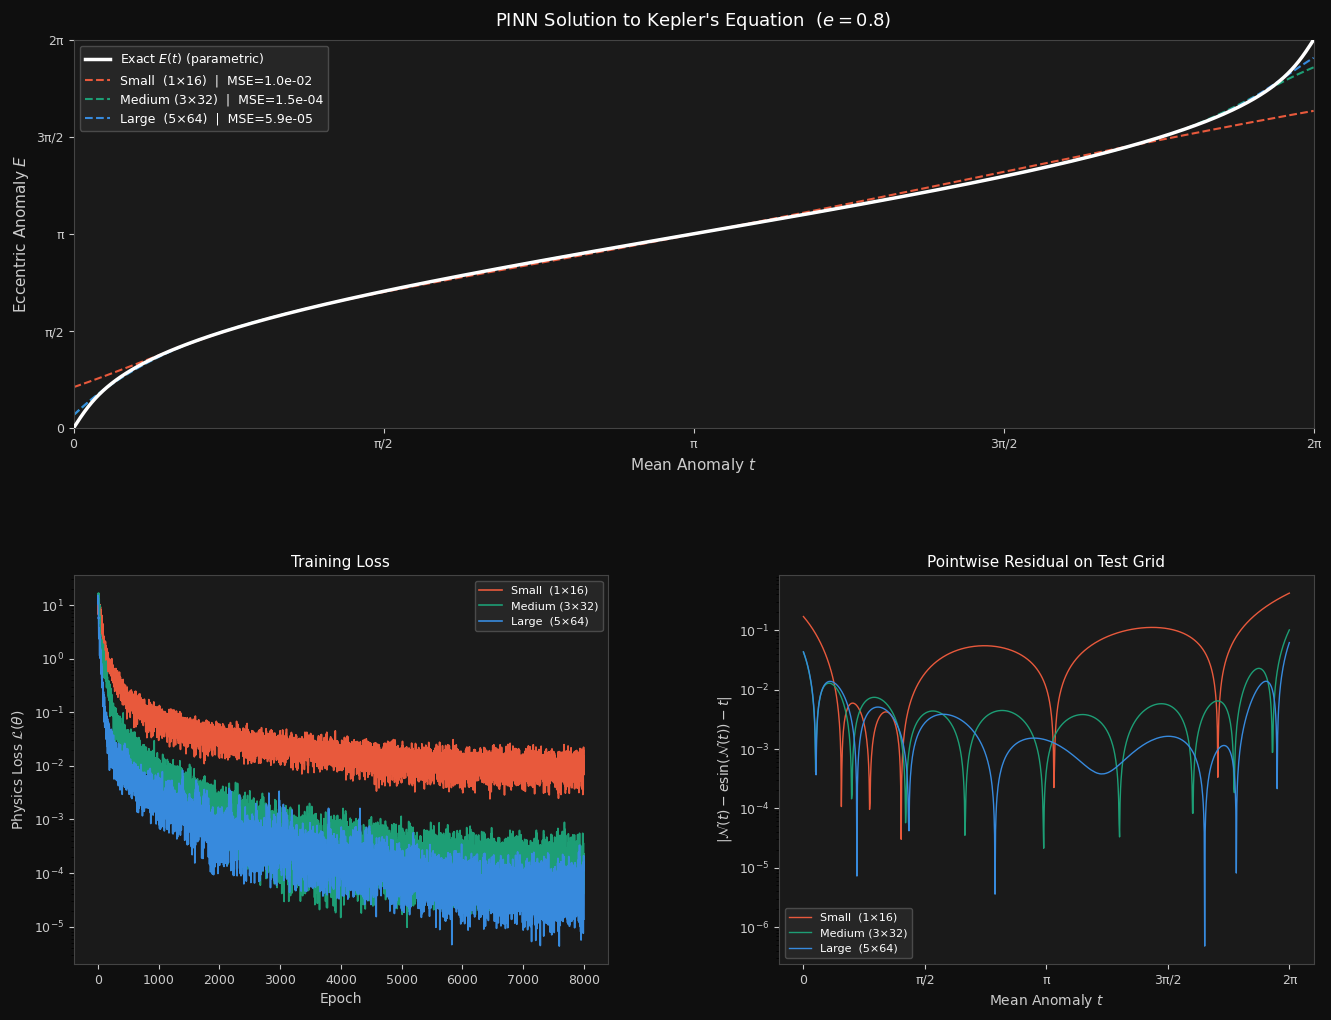

Plot saved.


In [6]:
t_np = t_test.numpy().flatten()
colors = ['#E8593C', '#1D9E75', '#378ADD']

fig = plt.figure(figsize=(16, 12))
fig.patch.set_facecolor('#0f0f0f')
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

ax_main  = fig.add_subplot(gs[0, :])   # top: E(t) curves
ax_loss  = fig.add_subplot(gs[1, 0])   # bottom-left: loss curves
ax_resid = fig.add_subplot(gs[1, 1])   # bottom-right: pointwise residual

for ax in [ax_main, ax_loss, ax_resid]:
    ax.set_facecolor('#1a1a1a')
    ax.tick_params(colors='#cccccc', labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor('#444444')

# ── Top: E(t) approximations ──
ax_main.plot(t_ref, E_ref, color='white', lw=2.5, label='Exact $E(t)$ (parametric)', zorder=5)
for (name, res), c in zip(results.items(), colors):
    ax_main.plot(t_np, res['E_pred'], color=c, lw=1.5, ls='--',
                 label=f"{name}  |  MSE={res['test_mse']:.1e}")

ax_main.set_xlabel('Mean Anomaly $t$', color='#cccccc', fontsize=11)
ax_main.set_ylabel('Eccentric Anomaly $E$', color='#cccccc', fontsize=11)
ax_main.set_title('PINN Solution to Kepler\'s Equation  ($e=0.8$)', color='white', fontsize=13, pad=10)
ax_main.legend(fontsize=9, facecolor='#2a2a2a', edgecolor='#555555', labelcolor='white')
ax_main.set_xlim(0, 2*np.pi); ax_main.set_ylim(0, 2*np.pi)
ax_main.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_main.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], color='#cccccc')
ax_main.set_yticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_main.set_yticklabels(['0', 'π/2', 'π', '3π/2', '2π'], color='#cccccc')

# ── Bottom-left: training loss ──
for (name, res), c in zip(results.items(), colors):
    ax_loss.semilogy(res['history'], color=c, lw=1.2, label=name.strip())
ax_loss.set_xlabel('Epoch', color='#cccccc', fontsize=10)
ax_loss.set_ylabel('Physics Loss $\\mathcal{L}(\\theta)$', color='#cccccc', fontsize=10)
ax_loss.set_title('Training Loss', color='white', fontsize=11)
ax_loss.legend(fontsize=8, facecolor='#2a2a2a', edgecolor='#555555', labelcolor='white')
ax_loss.yaxis.label.set_color('#cccccc')
ax_loss.tick_params(axis='y', colors='#cccccc')

# ── Bottom-right: pointwise absolute residual ──
for (name, res), c in zip(results.items(), colors):
    E_p = res['E_pred']
    abs_res = np.abs(E_p - E_ORBIT * np.sin(E_p) - t_np)
    ax_resid.semilogy(t_np, abs_res, color=c, lw=1.0, label=name.strip())

ax_resid.set_xlabel('Mean Anomaly $t$', color='#cccccc', fontsize=10)
ax_resid.set_ylabel('$|\\mathcal{N}(t) - e\\sin(\\mathcal{N}(t)) - t|$', color='#cccccc', fontsize=10)
ax_resid.set_title('Pointwise Residual on Test Grid', color='white', fontsize=11)
ax_resid.legend(fontsize=8, facecolor='#2a2a2a', edgecolor='#555555', labelcolor='white')
ax_resid.set_xticks([0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi])
ax_resid.set_xticklabels(['0', 'π/2', 'π', '3π/2', '2π'], color='#cccccc')
ax_resid.tick_params(axis='y', colors='#cccccc')

plt.savefig('kepler_pinn_results.png', dpi=150, bbox_inches='tight',
            facecolor='#0f0f0f')
plt.show()
print('Plot saved.')

## Discussion

**Effect of network size.** A deeper, wider network has more expressive power and consistently achieves a lower physics residual. For $e=0.8$ (high eccentricity), Kepler's equation is highly nonlinear — the mapping $t \mapsto E$ deviates substantially from a straight line, so a single hidden layer with 16 units cannot represent it with high fidelity. The medium and large networks capture the nonlinearity much better.

**Why this is a PINN.** No labeled training data was used at any point. The loss is purely the squared residual of the governing equation, evaluated at randomly drawn collocation points. The physics — Kepler's equation — acts as the sole training signal.

**Evaluating accuracy without a solver.** Since no analytic formula for $E(t)$ exists, we assess accuracy via the test MSE residual $\mathcal{L}(\theta)$ on a 1000-point grid and visually against the parametric reference curve $(t, E) = (E - e\sin E, E)$.